In [1]:
!pip install -q diffusers transformers accelerate peft safetensors sentencepiece protobuf

In [ ]:
from huggingface_hub import login
import os


login(token=HF_TOKEN)



In [3]:
import importlib
import torchao
print(torchao.__version__)
print(torchao.__file__)


0.10.0
/usr/local/lib/python3.12/dist-packages/torchao/__init__.py


In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [5]:
import torch
print(torch.cuda.is_available())       # should print True
print(torch.cuda.get_device_name(0))   # should print something like "Tesla T4"


True
Tesla T4


In [6]:
import torch
from diffusers import FluxPipeline

pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    torch_dtype=torch.bfloat16,
)
pipe.enable_model_cpu_offload()  # moves layers to GPU only when needed

print(f"Model type: {type(pipe.transformer).__name__}")
print(f"Scheduler:  {type(pipe.scheduler).__name__}")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model type: FluxTransformer2DModel
Scheduler:  FlowMatchEulerDiscreteScheduler


In [7]:
from google.colab import files
import os

os.makedirs("/content/loras", exist_ok=True)
uploaded = files.upload()  # opens a file picker dialog

for fname in uploaded:
    os.rename(fname, f"/content/loras/{fname}")
    print(f"Saved: /content/loras/{fname}")


Saving character_lora.safetensors to character_lora.safetensors
Saving style_lora.safetensors to style_lora.safetensors
Saved: /content/loras/character_lora.safetensors
Saved: /content/loras/style_lora.safetensors


In [9]:
!pip install --force-reinstall "torchao>=0.16.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [10]:
pipe.unload_lora_weights()

pipe.load_lora_weights("/content/loras", weight_name="style_lora.safetensors", adapter_name="style")
pipe.load_lora_weights("/content/loras", weight_name="character_lora.safetensors", adapter_name="character")
ADAPTERS = ["style", "character"]
pipe.set_adapters(ADAPTERS)


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [11]:
SEED = 42

PROMPT = "portrait photo of a woman, leeb01, cinematic realism, soft natural skin texture, golden hour sunlight, garden background, shallow depth of field, 35mm photography"

GEN_KW = dict(
    prompt=PROMPT,
    height=512,   # reduced from 768
    width=512,    # reduced from 768
    num_inference_steps=4,
    guidance_scale=0.0,
    max_sequence_length=256,
)



In [12]:
import torch, gc

# Free up memory
gc.collect()
torch.cuda.empty_cache()

# Enable memory-efficient attention and CPU offloading
pipe.enable_sequential_cpu_offload()   # offloads layers to CPU when not in use
pipe.enable_attention_slicing()


In [13]:
import time

pipe.set_adapters(ADAPTERS)

t0 = time.time()
img_merge = pipe(
    **GEN_KW,
    generator=torch.manual_seed(SEED),
).images[0]
t_merge = time.time() - t0

print(f"Merge: {t_merge:.1f}s")
img_merge

  0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [18]:
generator=torch.Generator(device="cuda").manual_seed(11)

In [19]:
from tqdm import tqdm

@torch.no_grad()
def flux_composite(pipe, adapter_names, prompt, height, width,
                   num_steps=4, generator=None, max_seq_len=256):
    """
    LoRA Composite for Flow Matching.
    Runs the transformer once per LoRA per step, averages velocity predictions.
    """
    device = pipe._execution_device
    dtype  = pipe.transformer.dtype

    # ---- 1. Encode text (shared across all LoRAs) ----
    prompt_embeds, pooled_prompt_embeds, text_ids = pipe.encode_prompt(
        prompt=prompt,
        prompt_2=prompt,
        max_sequence_length=max_seq_len,
    )

    # ---- 2. Prepare initial noise ----
    # Flux packs latents into 2x2 patches
    vae_sf   = pipe.vae_scale_factor       # typically 16
    latent_h = 2 * (height // (vae_sf * 2))
    latent_w = 2 * (width  // (vae_sf * 2))
    channels = pipe.transformer.config.in_channels // 4

    latents = torch.randn(
        1, channels, latent_h, latent_w,
        device=device, dtype=dtype, generator=generator,
    )

    # Prepare positional IDs and pack latents (Flux-specific)
    latent_image_ids = pipe._prepare_latent_image_ids(
        1, latent_h // 2, latent_w // 2, device, dtype
    )
    latents = pipe._pack_latents(latents, 1, channels, latent_h, latent_w)

    # ---- 3. Set up timesteps ----
    pipe.scheduler.set_timesteps(num_steps, device=device)
    timesteps = pipe.scheduler.timesteps

    # ---- 4. Denoising loop with velocity averaging ----
    for i, t in enumerate(tqdm(timesteps, desc="Composite")):
        vel_preds = []

        for adapter in adapter_names:
            # Activate only this LoRA
            pipe.set_adapters([adapter])

            # Transformer predicts velocity
            v_pred = pipe.transformer(
                hidden_states=latents,
                timestep=t.expand(1) / 1000.0,
                pooled_projections=pooled_prompt_embeds,
                encoder_hidden_states=prompt_embeds,
                txt_ids=text_ids,
                img_ids=latent_image_ids,
                return_dict=False,
            )[0]
            vel_preds.append(v_pred)

        # Average velocity predictions from all LoRAs
        avg_vel = torch.stack(vel_preds).mean(dim=0)

        # Euler step: x_{t+dt} = x_t + v * dt
        latents = pipe.scheduler.step(avg_vel, t, latents, return_dict=False)[0]

    # Re-enable all adapters
    pipe.set_adapters(adapter_names)

    # ---- 5. Decode latents to image ----
    latents = pipe._unpack_latents(latents, height, width, vae_sf)
    latents = (latents / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
    image   = pipe.vae.decode(latents, return_dict=False)[0]
    return pipe.image_processor.postprocess(image, output_type="pil")[0]

print("flux_composite() defined.")

flux_composite() defined.


Composite: 100%|██████████| 4/4 [13:13<00:00, 198.40s/it]


Composite: 837.9s


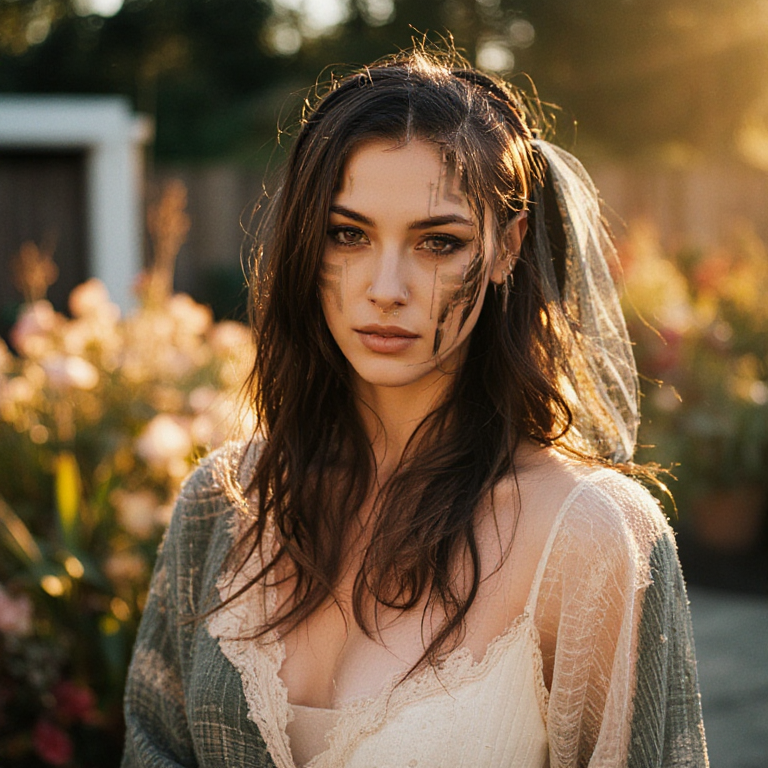

In [21]:
t0 = time.time()
img_composite = flux_composite(
    pipe,
    adapter_names=ADAPTERS,
    prompt=PROMPT,
    height=768, width=768,
    num_steps=4,
    generator=torch.Generator(device="cuda").manual_seed(11),

)
t_composite = time.time() - t0

print(f"Composite: {t_composite:.1f}s")
img_composite

In [ ]:
from peft.tuners.lora import LoraLayer


def _energy_truncate(U, S, thresh):
    """Keep fewest columns of U that capture >= thresh of total S^2 energy."""
    cum = torch.cumsum(S ** 2, dim=0) / (S ** 2).sum()
    k   = int((cum < thresh).sum().item()) + 1
    return U[:, :max(1, min(k, S.shape[0]))]


class SubspaceLoRAComposer:

    def __init__(self, pipe):
        self.pipe  = pipe
        # ---- THE KEY CHANGE: auto-detect UNet vs Transformer ----
        self.model = getattr(pipe, 'transformer', None) or pipe.unet
        self._saved           = {}
        self._active_adapters = []

    def _base_weight(self, module):
        return module.base_layer.weight if hasattr(module, "base_layer") else module.weight

    def _merged_delta(self, module, adapters, w_dict, energy_thresh):
        B_pool, A_pool = [], []
        raw_B, raw_A   = [], []
        sqrt_scales    = []

        for name in adapters:
            A = module.lora_A[name].weight.data.float()
            B = module.lora_B[name].weight.data.float()
            s_i    = module.lora_alpha[name] / module.r[name]
            sqrt_s = s_i ** 0.5

            B_tilde = B / (B.norm() + 1e-8)
            A_tilde = A / (A.norm() + 1e-8)

            B_pool.append(B_tilde)
            A_pool.append(A_tilde.T)
            raw_B.append(B)
            raw_A.append(A)
            sqrt_scales.append(sqrt_s)

        # SVD on pooled directions
        P_B = torch.cat(B_pool, dim=1)
        P_A = torch.cat(A_pool, dim=1)

        U_B_full, S_B, _ = torch.linalg.svd(P_B, full_matrices=False)
        V_A_full, S_A, _ = torch.linalg.svd(P_A, full_matrices=False)

        U_B = _energy_truncate(U_B_full, S_B, energy_thresh)
        V_A = _energy_truncate(V_A_full, S_A, energy_thresh)

        # Project and compose in subspace
        k_B, k_A = U_B.shape[1], V_A.shape[1]
        C_sum = torch.zeros(k_B, k_A, device=U_B.device, dtype=torch.float32)

        for B, A, sqrt_s, name in zip(raw_B, raw_A, sqrt_scales, adapters):
            B_hat = sqrt_s * (U_B.T @ B)
            A_hat = sqrt_s * (A @ V_A)
            C_sum += w_dict.get(name, 1.0) * (B_hat @ A_hat)

        return (U_B @ C_sum @ V_A.T).to(self._base_weight(module).dtype)

    def apply(self, adapter_names, weights=None, energy_thresh=0.95, lora_scale=1.0):
        w_dict = {n: (weights or {}).get(n, 1.0) for n in adapter_names}
        self._active_adapters = list(adapter_names)
        self._saved.clear()

        # ---- Uses self.model (transformer or unet) ----
        for layer_name, module in self.model.named_modules():
            if not isinstance(module, LoraLayer):
                continue
            if not all(a in module.lora_A for a in adapter_names):
                continue
            bw = self._base_weight(module)
            if bw.dim() != 2:
                continue
            dW = self._merged_delta(module, adapter_names, w_dict, energy_thresh)
            self._saved[layer_name] = bw.data.clone()
            bw.data += (lora_scale * dW).to(bw.device)

        try:
            self.model.disable_adapter_layers()
        except AttributeError:
            self.pipe.set_adapters(adapter_names, [0.0] * len(adapter_names))

    def restore(self):
        for layer_name, module in self.model.named_modules():
            if layer_name in self._saved:
                self._base_weight(module).data = self._saved[layer_name]
        self._saved.clear()
        try:
            self.model.enable_adapter_layers()
        except AttributeError:
            self.pipe.set_adapters(self._active_adapters,
                                   [1.0] * len(self._active_adapters))

    def __call__(self, adapter_names, weights=None,
                 energy_thresh=0.95, lora_scale=1.0, **pipe_kwargs):
        self.apply(adapter_names, weights=weights,
                   energy_thresh=energy_thresh, lora_scale=lora_scale)
        try:
            result = self.pipe(**pipe_kwargs)
        finally:
            self.restore()
        return result.images[0]

print("SubspaceLoRAComposer defined (auto-detects UNet vs Transformer).")

In [ ]:
composer = SubspaceLoRAComposer(pipe)

t0 = time.time()
img_subspace = composer(
    adapter_names=ADAPTERS,
    energy_thresh=0.95,
    lora_scale=1.0,
    generator=torch.manual_seed(SEED),
    **GEN_KW,
)
t_subspace = time.time() - t0

print(f"LORASPACE: {t_subspace:.1f}s")
img_subspace

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, img, title in zip(axes,
    [img_merge, img_composite, img_subspace],
    [f"LoRA Merge\n{t_merge:.0f}s",
     f"LoRA Composite\n{t_composite:.0f}s",
     f"LORASPACE\n{t_subspace:.0f}s"]):
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.suptitle("Flow Matching (Flux) — Multi-LoRA Composition Comparison", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("flux_lora_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Merge: {t_merge:.1f}s | Composite: {t_composite:.1f}s | LORASPACE: {t_subspace:.1f}s")